# Project 1: Multi-Stock Return & Risk Analysis
**Universe:** GRAB (Grab), SE (Sea) — ASEAN Internet | 5225.KL (IHH Healthcare), KLBF.JK (Kalbe Farma), BDMS.BK (Bangkok Dusit Medical Services) — ASEAN Healthcare

This notebook pulls daily price data across four exchanges with different trading calendars, forward-fills non-trading-day gaps, and analyzes returns, correlation, and rolling volatility — testing whether a shared "sector" label actually implies correlated price behavior.

In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

TICKERS = ["GRAB", "SE", "5225.KL", "KLBF.JK", "BDMS.BK"]
START = "2025-01-01"
END = "2025-09-01"

## Step 1: Pull and clean price data
Different exchanges (US, Malaysia, Indonesia, Thailand) have different holiday calendars. Rather than drop any day where *any* one market was closed, we forward-fill — carrying the last known price forward — so we don't lose data unnecessarily.

In [2]:
price_data = yf.download(TICKERS, start=START, end=END)
closes = price_data["Close"]
closes_filled = closes.ffill()

print("Missing values after forward-fill:")
print(closes_filled.isna().sum())
closes_filled.tail()

/tmp/ipykernel_4302/2286078334.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(TICKERS, start=START, end=END)
[*********************100%***********************]  5 of 5 completed

Missing values after forward-fill:
Ticker
5225.KL    0
BDMS.BK    0
GRAB       0
KLBF.JK    0
SE         0
dtype: int64


Ticker,5225.KL,BDMS.BK,GRAB,KLBF.JK,SE
Date,,,,,
2025-08-25,6.657578,19.512060,5.01,1264.383545,187.550003
2025-08-26,6.637968,19.325346,5.00,1254.657471,188.289993
2025-08-27,6.657578,19.418701,4.95,1254.657471,182.910004
2025-08-28,6.657578,19.418701,4.97,1235.205444,186.240005
2025-08-29,6.657578,19.325346,4.99,1181.712280,186.539993


## Step 2: Calculate daily returns

In [3]:
returns = closes_filled.pct_change().dropna()
returns.tail()

Ticker,5225.KL,BDMS.BK,GRAB,KLBF.JK,SE
Date,,,,,
2025-08-25,-0.007310,-0.004762,-0.023392,-0.040590,0.010888
2025-08-26,-0.002946,-0.009569,-0.001996,-0.007692,0.003946
2025-08-27,0.002954,0.004831,-0.010000,0.000000,-0.028573
2025-08-28,0.000000,0.000000,0.004040,-0.015504,0.018206
2025-08-29,0.000000,-0.004807,0.004024,-0.043307,0.001611


## Step 3: Correlation matrix
**Question:** does sharing a sector label (Internet vs. Healthcare) actually predict correlation?

In [4]:
corr_matrix = returns.corr()
corr_matrix

Ticker,5225.KL,BDMS.BK,GRAB,KLBF.JK,SE
Ticker,,,,,
5225.KL,1.000000,0.003616,-0.024043,-0.077608,-0.124712
BDMS.BK,0.003616,1.000000,0.149657,0.054359,0.069703
GRAB,-0.024043,0.149657,1.000000,0.097981,0.485752
KLBF.JK,-0.077608,0.054359,0.097981,1.000000,0.078413
SE,-0.124712,0.069703,0.485752,0.078413,1.000000


**Finding:** GRAB–SE (both "Internet") correlate at ~0.49 — meaningfully positive. IHH–BDMS (both "Healthcare," but different countries — Malaysia vs. Thailand) correlate at ~0.00 — essentially no relationship. Sector labels alone don't guarantee comparable price behavior; country/currency/regulatory exposure can matter more.

## Step 4: 20-day rolling volatility

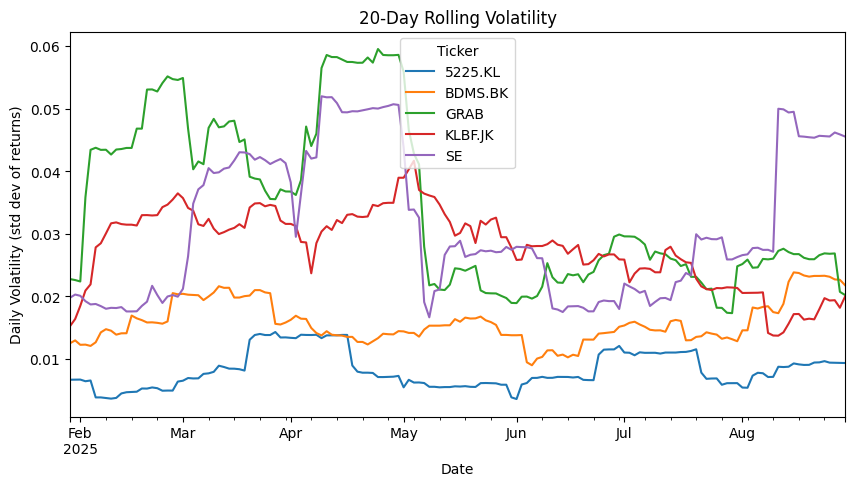

In [5]:
rolling_vol = returns.rolling(window=20).std().dropna()

rolling_vol.plot(figsize=(10, 5), title="20-Day Rolling Volatility")
plt.ylabel("Daily Volatility (std dev of returns)")
plt.show()

**Finding:** SE shows a sharp volatility spike in mid/late August. Tracing this back to the underlying daily returns (not just the smoothed rolling average) identifies the exact cause:

In [6]:
print("SE's most extreme single-day returns:")
print(returns["SE"].sort_values())

SE's most extreme single-day returns:
Date
2025-04-04   -0.111787
2025-04-03   -0.107966
2025-07-21   -0.078671
2025-03-10   -0.061685
2025-07-01   -0.059022
                ...   
2025-03-04    0.071423
2025-05-13    0.081994
2025-03-05    0.105812
2025-04-09    0.128067
2025-08-12    0.190727
Name: SE, Length: 171, dtype: float64


**Verified finding:** SE's single largest move was **+19.07% on Aug 12, 2025** — independently confirmed against Sea Limited's actual Q2 2025 earnings release, which showed a revenue beat of roughly $300M (despite a narrow EPS miss), driving the rally. This confirms the chart anomaly against a real, sourced market event rather than leaving it as an unexplained statistical artifact.

## Summary
- Built a cross-market data pipeline handling real-world messiness (mismatched trading calendars, MultiIndex columns from multi-ticker downloads).
- Found that sector classification alone is a weak predictor of correlation in this sample — GRAB/SE correlate meaningfully more than IHH/BDMS despite the latter sharing a sector label.
- Demonstrated end-to-end anomaly tracing: chart → raw data → external verification.
